# Argus — CNN+LSTM Training (Windowed Face-Crop Sequences)

Trains the fifth model family: a `TimeDistributed(CNN) → LSTM` hybrid that sees an actual
windowed *sequence* of face-crop images, combining raw-pixel visual cues (which the
hand-engineered geometric features never captured) with genuine temporal context (which
07_cnn_training.ipynb's single-frame CNN can't see at all). See the root `CLAUDE.md`'s
"Why CNN is the most probable next backbone" for the full reasoning.

**Calibrated expectation, carried over from `09_dataset_creation_cnn_lstm.ipynb`:** this is, by
a wide margin, the most data-hungry model built so far in this project — a deep model over raw
pixel *sequences*, trained on however many subjects exist in `raw_videos/` at extraction time.
Real overfitting risk here is higher than anywhere else in this project, not lower. Worth
trying — it's the theoretically strongest architecture for this problem — but don't assume
"more complete architecture" automatically means "better result"; treat this as a real
experiment with a real chance of underperforming both 07's single-frame CNN and the geometric
LSTM, not a foregone upgrade.

**Reads:** `dataset_processed/cnn_lstm_windows_index.csv`, written by
[`09_dataset_creation_cnn_lstm.ipynb`](./09_dataset_creation_cnn_lstm.ipynb) — run that first.

**Writes:** `models/cnn_lstm_scratch_<VERSION>.keras` and
`models/cnn_lstm_mobilenet_<VERSION>.keras`.

**Two backbones, trained side by side, same shape as `07_cnn_training.ipynb`'s scratch-vs-
MobileNetV2 comparison:**
1. A **from-scratch CNN** (07's own conv-stack architecture, minus its final classification
   head) as the per-frame feature extractor.
2. A **MobileNetV2** feature extractor — but deliberately *not* 07's exact `(alpha=0.35,
   IMG_SIZE=96)` config, which collapsed there (16.81% accuracy, zero recall on `Low Vigilant`).
   `notebook/CLAUDE.md`'s "Cheaper options" section diagnoses that as more likely a
   resolution/`alpha` mismatch (a ~3×3 feature map before pooling) than a real verdict against
   pretraining, and names "a higher input resolution or larger `alpha`" as the untried fix —
   applied here (`alpha=1.0`, `IMG_SIZE_MOBILENET=128`) to give it a real shot rather than
   reproducing the same collapse inside a more expensive model.

Both share the same `LSTM(64) → Dropout → Dense(3, softmax)` head, the same subject-grouped
split, the same focal-loss/class-weight setup, and the same val-macro-F1-based checkpointing —
so any accuracy difference between them is attributable to the backbone, not to a different
training setup, mirroring 07's own framing.

## Google Drive Connection & Project Setup


In [1]:
from google.colab import drive
import os
import datetime
import pandas as pd

drive.mount('/content/drive')

# --- Argus project paths (must match 09_dataset_creation_cnn_lstm.ipynb) ---
project_folder = "/content/drive/MyDrive/Argus"
models_folder = f"{project_folder}/models"
dataset_folder = f"{project_folder}/dataset"
processed_folder = f"{dataset_folder}/dataset_processed"
cnn_lstm_windows_csv_path = os.path.join(processed_folder, "cnn_lstm_windows_index.csv")

if not os.path.exists(cnn_lstm_windows_csv_path):
    raise FileNotFoundError(
        f"'{cnn_lstm_windows_csv_path}' not found. Run 09_dataset_creation_cnn_lstm.ipynb "
        "first -- this notebook only trains against the window index it produces, it doesn't "
        "build it."
    )

df_cnn_lstm_windows = pd.read_csv(cnn_lstm_windows_csv_path)
print(f"Loaded window index: {len(df_cnn_lstm_windows)} windows, "
      f"{df_cnn_lstm_windows['subject'].nunique()} subjects.")

# --- Model Management Configuration ---
FORCE_RETRAIN = True
VERSION_STR = datetime.datetime.now().strftime("%Y%m%d_%H%M")
cnn_lstm_scratch_model_path = os.path.join(models_folder, f"cnn_lstm_scratch_{VERSION_STR}.keras")
cnn_lstm_mobilenet_model_path = os.path.join(models_folder, f"cnn_lstm_mobilenet_{VERSION_STR}.keras")

def get_latest_model(folder, prefix, extension):
    """Return the path of the most recently versioned model matching prefix/extension, or None."""
    if not os.path.exists(folder):
        return None
    files = [f for f in os.listdir(folder) if f.startswith(prefix) and f.endswith(extension)]
    if not files:
        return None
    return os.path.join(folder, sorted(files)[-1])

print(f"✅ Model management initialized. Current version: {VERSION_STR}. Force retrain: {FORCE_RETRAIN}")


Mounted at /content/drive
Loaded window index: 5763 windows, 54 subjects.
✅ Model management initialized. Current version: 20260826_1340. Force retrain: True


## Splitting the Dataset

Group-aware split by subject, same rationale and same rule as `07_cnn_training.ipynb`'s
`split_by_subject_fold` — ported here **unchanged**, just called on the window index instead of
the crop index (same `subject`/`level` columns, same meaning: only subjects with all 3 classes
represented among their windows are eligible to be a held-out *test* subject; incomplete
subjects still contribute real training windows for whichever classes they have, and form the
validation pool). The split happens on the **index CSV** (window metadata + `;`-joined path
lists), before any image is decoded — pixel loading happens lazily in the `tf.data` pipeline
below, same as 07.


In [2]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np


def split_by_subject_fold(df, fold_idx=0, n_splits=None, random_state=42):
    """Subject-grouped train/val/test split, ported unchanged from 07_cnn_training.ipynb --
    parameterized by fold index so the same logic can drive both the main fold-0 split below and
    a future subject-fold cross-validation diagnostic, without duplicating the split rules.

    Only subjects with all 3 classes present are eligible to be picked as *test* subjects.
    Incomplete subjects (missing a class entirely) are NOT dropped from the dataset -- they're
    still valid training data for whichever classes they have -- they're just never candidates
    for the held-out fold, since a test fold drawn from them could be missing a class no matter
    how the split algorithm balances things. Validation = the incomplete-subject pool, genuinely
    held out and structurally incapable of leaking into test-fold selection.

    Returns (df_train, df_val, df_test, complete_subjects, incomplete_subjects, n_splits_used).
    """
    subject_level_sets = df.groupby('subject')['level'].agg(set)
    complete_subjects = subject_level_sets[subject_level_sets == {1, 2, 3}].index
    incomplete_subjects = subject_level_sets.index.difference(complete_subjects)

    if len(complete_subjects) < 2:
        raise ValueError(
            f"Only {len(complete_subjects)} subject(s) have all 3 classes ({list(complete_subjects)}) "
            "-- need at least 2 to hold one out for testing. Finish dataset extraction "
            "(06_dataset_creation_face_crops.ipynb + 09_dataset_creation_cnn_lstm.ipynb) for "
            "more subjects before training."
        )

    df_complete = df[df['subject'].isin(complete_subjects)]
    n_splits = n_splits or min(5, len(complete_subjects))
    if not (0 <= fold_idx < n_splits):
        raise ValueError(f"fold_idx={fold_idx} out of range for n_splits={n_splits}")

    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_iter = sgkf.split(df_complete, df_complete['level'], groups=df_complete['subject'])
    for i, (_, complete_test_pos) in enumerate(fold_iter):
        if i == fold_idx:
            break

    test_subjects = set(df_complete.iloc[complete_test_pos]['subject'])
    val_subjects = set(incomplete_subjects)

    test_mask = df['subject'].isin(test_subjects)
    val_mask = df['subject'].isin(val_subjects)
    train_mask = ~test_mask & ~val_mask

    df_train = df[train_mask].reset_index(drop=True)
    df_val = df[val_mask].reset_index(drop=True)
    df_test = df[test_mask].reset_index(drop=True)

    if len(df_val) == 0:
        raise ValueError(
            "No incomplete subjects available to build a validation set. Either every subject "
            "has all 3 classes (pick one complete subject out of the train pool manually "
            "instead) or the dataset changed shape unexpectedly."
        )

    return df_train, df_val, df_test, complete_subjects, incomplete_subjects, n_splits


df_train, df_val, df_test, complete_subjects, incomplete_subjects, N_SPLITS = split_by_subject_fold(
    df_cnn_lstm_windows, fold_idx=0
)
print(f"Complete-class subjects ({len(complete_subjects)}): {list(complete_subjects)}")
print(f"Incomplete subjects ({len(incomplete_subjects)}): {list(incomplete_subjects)}")
print(f"Train: {len(df_train)} windows, Val: {len(df_val)} windows, Test: {len(df_test)} windows")
print(f"Test-fold windows by duration:\n{df_test['window_duration_sec'].value_counts().sort_index()}")


Complete-class subjects (48): ['subject_03', 'subject_04', 'subject_07', 'subject_08', 'subject_09', 'subject_10', 'subject_11', 'subject_12', 'subject_13', 'subject_14', 'subject_15', 'subject_16', 'subject_17', 'subject_18', 'subject_19', 'subject_20', 'subject_21', 'subject_22', 'subject_23', 'subject_24', 'subject_25', 'subject_26', 'subject_27', 'subject_28', 'subject_29', 'subject_30', 'subject_31', 'subject_32', 'subject_33', 'subject_34', 'subject_35', 'subject_36', 'subject_37', 'subject_39', 'subject_40', 'subject_41', 'subject_42', 'subject_43', 'subject_44', 'subject_45', 'subject_46', 'subject_47', 'subject_48', 'subject_49', 'subject_50', 'subject_51', 'subject_53', 'subject_54']
Incomplete subjects (6): ['subject_01', 'subject_02', 'subject_05', 'subject_06', 'subject_38', 'subject_52']
Train: 4359 windows, Val: 234 windows, Test: 1170 windows
Test-fold windows by duration:
window_duration_sec
3.0     540
5.0     360
10.0    180
20.0     90
Name: count, dtype: int64


## Building the `tf.data` Pipeline

Each row's `image_paths` (`;`-joined) has exactly `n_real_frames` real images (3/5/10/20 — no
partial windows, see `09`). Per window:

1. Split the path list, decode + resize each real frame.
2. Zero-**pre**-pad to `MAX_TIMESTEPS_IMG=20` (zeros first, real frames last) — matching this
   project's established rolling-buffer convention (root `CLAUDE.md`: padding has to match how a
   live buffer actually fills, oldest-dropped/newest-appended).
3. Build a boolean mask of shape `(MAX_TIMESTEPS_IMG,)` **directly from the already-known
   `n_real_frames` value**, not by inferring it from all-zero pixels. A plain Keras `Masking`
   layer only reduces over the *last* axis of its input — that's exactly right for the geometric
   LSTM's all-zero 58-float timestep, but wrong for an all-zero `(H, W, 3)` image timestep here.
   Computing the mask from the known real length sidesteps that entirely, and is strictly more
   correct anyway: a genuinely all-black *real* frame would never be misdetected as padding this
   way, unlike with a value-based `Masking` layer.
4. Feed the mask directly into the `LSTM` layer's `call()` (`LSTM(...)(x, mask=mask_input)`) —
   the officially-supported way to pass an explicit mask to a Keras RNN layer — rather than a
   preceding `Masking` layer.

**Window-level augmentation, not per-frame.** Every frame in a window is the same continuous
stretch of one clip, so flip/rotation/zoom/contrast/brightness must be sampled **once per
window** and applied identically to every real frame in it — flipping frame 3 but not frame 7 of
the same window would be incoherent. Calling `tf.keras.layers.Random*` directly on a
`(T, H, W, C)` tensor would sample independently per leading-axis entry (its normal batch
behavior), reproducing exactly that wrong per-frame-independent behavior — so rotation/zoom/
contrast are applied via a fold-time-into-channels trick instead (`(T,H,W,3) → (1,H,W,T*3)`,
augment once, unfold), and flip/brightness via one manually-sampled decision applied to the whole
window at once.

**Per-frame Gaussian noise is the one exception — applied independently per real frame,
deliberately.** Real camera sensor noise genuinely varies frame to frame in actual video, unlike
flip/rotation/zoom (properties of the whole camera framing), so sampling it independently per
frame is the *realistic* choice here, not a bug to avoid.

**`BATCH_SIZE=8` / `BATCH_SIZE_MOBILENET=4`, both down from 07's 32.** Each padded scratch-CNN
example is `20×96×96×3` floats — roughly 20x heavier than one of 07's single images — and the
MobileNetV2 variant's larger `128×128` frames make its examples heavier still, so both batch
sizes are reduced accordingly rather than left at 07's value.


In [3]:
import tensorflow as tf
import numpy as np

MAX_TIMESTEPS_IMG = 20                 # Must match 09_dataset_creation_cnn_lstm.ipynb's own
                                        # MAX_TIMESTEPS_IMG (max_context_sec * sampling_fps = 20*1).
IMG_SIZE = 96                          # From-scratch CNN input resolution -- same as 07 (same
                                        # underlying crops, no reason to change it here).
IMG_SIZE_MOBILENET = 128               # Deliberately larger than 96 -- see the Model section
                                        # below for why (07's alpha=0.35/96x96 collapse).
BATCH_SIZE = 8                         # Down from 07's 32 -- see markdown above.
BATCH_SIZE_MOBILENET = 4               # Smaller still: larger resolution + a heavier backbone.
CLASS_NAMES = ['Alert', 'Low Vigilant', 'Drowsy']
NOISE_STDDEV = 0.03                    # Std-dev of additive Gaussian noise on a [0,255]-scaled
                                        # image (applied as NOISE_STDDEV * 255) -- a conservative
                                        # starting point; sanity-check visually before trusting it
                                        # (see "Augmented Sample Preview" below), same bar 07's own
                                        # augmentation choices were held to.


def _decode_and_resize(path, img_size):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, [img_size, img_size])
    return image  # float32, [0, 255] range -- Rescaling(1/255) happens inside the model, as in 07


def load_window(image_paths_str, n_real_frames, label, img_size, max_timesteps):
    """One window row -> (padded_images, mask, label).

    `n_real_frames` is the exact, already-known count of real frames (not inferred). Padding is
    zero-*pre*-padded (zeros first, real frames last) to match this project's rolling-buffer
    convention.
    """
    paths = tf.strings.split(image_paths_str, ';')
    real_images = tf.map_fn(
        lambda p: _decode_and_resize(p, img_size), paths, fn_output_signature=tf.float32,
    )  # (n_real_frames, img_size, img_size, 3)

    pad_amount = max_timesteps - n_real_frames
    padded_images = tf.pad(real_images, [[pad_amount, 0], [0, 0], [0, 0], [0, 0]])
    padded_images.set_shape([max_timesteps, img_size, img_size, 3])

    mask = tf.range(max_timesteps) >= pad_amount  # True for the last n_real_frames positions

    return padded_images, mask, label


# Same rotation/zoom/contrast augmenter as 07's geometric_augmenter, reused via the fold/unfold
# trick below so ONE random draw covers the whole window instead of one draw per frame.
geometric_augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),   # ~+/-18 degrees, same as 07
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
])


def _apply_shared_geometric_augmentation(images, img_size):
    """Applies `geometric_augmenter` with ONE shared random draw across every frame in the
    window. Keras preprocessing layers sample an independent transform per element of whatever
    leading axis they're given -- calling them directly on images shaped (T, H, W, 3) would
    reproduce 07's independent-per-image behavior, wrong for a sequence. Folding time into the
    channel axis first -- (T, H, W, 3) -> (1, H, W, T*3) -- makes the layer see one single image
    with many channels instead of T separate images, so it draws one transform for the whole
    thing; unfolding afterward restores the per-frame tensor.
    """
    t = tf.shape(images)[0]
    folded = tf.reshape(tf.transpose(images, [1, 2, 0, 3]), [1, img_size, img_size, -1])
    folded = geometric_augmenter(folded, training=True)
    unfolded = tf.reshape(folded, [img_size, img_size, t, 3])
    return tf.transpose(unfolded, [2, 0, 1, 3])


def augment_window(images, mask, label, img_size):
    """Augmentation shared across every real frame in the window (flip/brightness/rotation/zoom/
    contrast), plus independent per-frame Gaussian noise -- see the markdown above for why noise
    is the one exception applied per-frame rather than per-window.
    """
    # --- Flip: one shared coin flip for the whole window ---
    do_flip = tf.random.uniform([]) < 0.5
    images = tf.cond(do_flip, lambda: tf.image.flip_left_right(images), lambda: images)

    # --- Brightness: one shared delta, added identically to every frame ---
    brightness_delta = tf.random.uniform([], -0.15, 0.15) * 255.0
    images = tf.clip_by_value(images + brightness_delta, 0.0, 255.0)

    # --- Rotation/zoom/contrast: one shared draw via the fold-into-channels trick ---
    images = _apply_shared_geometric_augmentation(images, img_size)

    # --- Per-frame Gaussian noise: independent per real timestep, deliberately ---
    noise = tf.random.normal(tf.shape(images), stddev=NOISE_STDDEV * 255.0)
    images = tf.clip_by_value(images + noise, 0.0, 255.0)

    return images, mask, label


def make_dataset(df, training: bool, img_size: int, batch_size: int):
    image_paths = df['image_paths'].to_numpy()
    n_real_frames = df['n_real_frames'].to_numpy(dtype=np.int32)
    labels = (df['level'].to_numpy(dtype=np.int32) - 1)  # 0-indexed: 0=Alert, 1=Low Vigilant, 2=Drowsy

    ds = tf.data.Dataset.from_tensor_slices((image_paths, n_real_frames, labels))
    ds = ds.map(
        lambda p, n, l: load_window(p, n, l, img_size, MAX_TIMESTEPS_IMG),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    if training:
        ds = ds.shuffle(buffer_size=2048, seed=42)
        ds = ds.map(lambda img, m, l: augment_window(img, m, l, img_size),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda img, m, l: ((img, m), l), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# --- From-scratch CNN datasets (IMG_SIZE=96) ---
train_ds = make_dataset(df_train, training=True, img_size=IMG_SIZE, batch_size=BATCH_SIZE)
val_ds = make_dataset(df_val, training=False, img_size=IMG_SIZE, batch_size=BATCH_SIZE)
test_ds = make_dataset(df_test, training=False, img_size=IMG_SIZE, batch_size=BATCH_SIZE)

# --- MobileNetV2 datasets (IMG_SIZE_MOBILENET=128) -- a separate pipeline, not a resize of the
# above, since the two backbones deliberately use different input resolutions (see Model below).
train_ds_mobilenet = make_dataset(df_train, training=True, img_size=IMG_SIZE_MOBILENET,
                                   batch_size=BATCH_SIZE_MOBILENET)
val_ds_mobilenet = make_dataset(df_val, training=False, img_size=IMG_SIZE_MOBILENET,
                                 batch_size=BATCH_SIZE_MOBILENET)
test_ds_mobilenet = make_dataset(df_test, training=False, img_size=IMG_SIZE_MOBILENET,
                                  batch_size=BATCH_SIZE_MOBILENET)

print(f"IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE} | "
      f"IMG_SIZE_MOBILENET={IMG_SIZE_MOBILENET}, BATCH_SIZE_MOBILENET={BATCH_SIZE_MOBILENET}")


IMG_SIZE=96, BATCH_SIZE=8 | IMG_SIZE_MOBILENET=128, BATCH_SIZE_MOBILENET=4


### Augmented Sample Preview

A cheap, direct sanity check before trusting the pipeline blind: pull one augmented training
window and confirm (a) the geometric augmentation (flip/rotation/zoom/contrast) looks identical
across every real frame, (b) the per-frame noise is visibly present but not so strong it obscures
the eye/mouth region, and (c) the mask's real-frame count matches `n_real_frames`, and the real
frames are the *last* positions (pre-padding), not the first.


Label: Drowsy, mask real-frame count: 5 (real frames occupy the LAST 5 of 20 positions -- pre-padding)


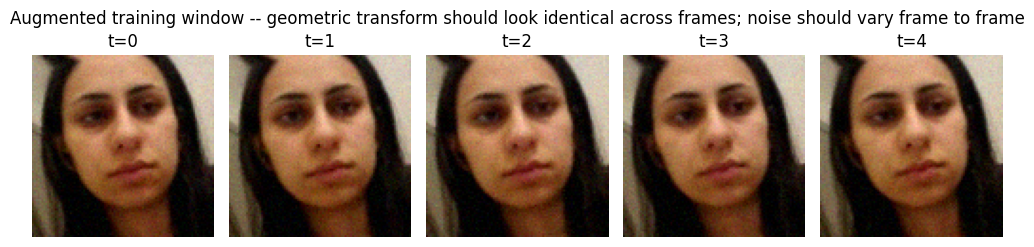

In [4]:
import matplotlib.pyplot as plt

for (sample_images, sample_mask), sample_label in train_ds.take(1):
    break

sample_idx = 0
images_np = sample_images[sample_idx].numpy()
mask_np = sample_mask[sample_idx].numpy()
n_real = int(mask_np.sum())

print(f"Label: {CLASS_NAMES[int(sample_label[sample_idx].numpy())]}, "
      f"mask real-frame count: {n_real} (real frames occupy the LAST {n_real} of "
      f"{MAX_TIMESTEPS_IMG} positions -- pre-padding)")
assert (mask_np[-n_real:]).all() and not (mask_np[:MAX_TIMESTEPS_IMG - n_real]).any(), \
    "Mask shape doesn't match the expected pre-padding layout -- check load_window's padding order."

real_frames = images_np[MAX_TIMESTEPS_IMG - n_real:]
n_preview = min(8, len(real_frames))
preview_idx = np.linspace(0, len(real_frames) - 1, n_preview, dtype=int)
fig, axes = plt.subplots(1, n_preview, figsize=(2 * n_preview, 2.5))
for ax, idx in zip(np.atleast_1d(axes), preview_idx):
    ax.imshow(np.clip(real_frames[idx] / 255.0, 0, 1))
    ax.set_title(f"t={idx}")
    ax.axis('off')
plt.suptitle("Augmented training window -- geometric transform should look identical across "
             "frames; noise should vary frame to frame")
plt.tight_layout()
plt.show()


## Loss Function

`SparseCategoricalFocalLoss`, ported unchanged from `07_cnn_training.ipynb` (same reasoning:
`Drowsy` is plausibly the rarest, most safety-critical class, and focal loss down-weights
easy/already-confident examples so training focuses on the harder, more ambiguous ones).


In [5]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy, CategoricalCrossentropy
import tensorflow as tf
import keras

num_classes = len(CLASS_NAMES)  # CLASS_NAMES defined earlier in "Building the tf.data Pipeline"

USE_FOCAL_LOSS = True
FOCAL_GAMMA = 2.0
LABEL_SMOOTHING = 0.05

@keras.saving.register_keras_serializable(package="CustomLosses")
class SparseCategoricalFocalLoss(keras.losses.Loss):
    def __init__(self, gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING,
                 reduction='sum_over_batch_size', name='sparse_categorical_focal_loss'):
        super().__init__(reduction=reduction, name=name)
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.cce_per_example = CategoricalCrossentropy(from_logits=False, reduction=None)

    def call(self, y_true, y_pred):
        y_true_int = tf.cast(y_true, tf.int32)
        num_classes_tensor = tf.shape(y_pred)[1]
        y_true_one_hot = tf.one_hot(y_true_int, depth=num_classes_tensor)

        if self.label_smoothing > 0.0:
            num_classes_float = tf.cast(num_classes_tensor, tf.float32)
            y_true_one_hot = y_true_one_hot * (1.0 - self.label_smoothing) + (self.label_smoothing / num_classes_float)

        ce = self.cce_per_example(y_true_one_hot, y_pred)
        probs_true_class = tf.reduce_sum(y_pred * y_true_one_hot, axis=-1)
        probs_true_class = tf.clip_by_value(probs_true_class, 1e-7, 1.0 - 1e-7)

        modulating_factor = tf.pow(1.0 - probs_true_class, self.gamma)
        return modulating_factor * ce

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'label_smoothing': self.label_smoothing})
        return config


def build_loss():
    if USE_FOCAL_LOSS:
        return SparseCategoricalFocalLoss(gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING)
    return SparseCategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)


## Model Definition — `TimeDistributed(CNN) → LSTM`

Two per-frame feature extractors, sharing the same recurrent head:

- **From-scratch:** 07's `build_cnn_scratch` conv stack (`Conv2D→BatchNorm→MaxPool` ×3, `l2`
  regularization), stopped at its `GlobalAveragePooling2D → Dense(64, relu, l2)` embedding — its
  final `Dense(3, softmax)` head is dropped, since classification happens after the LSTM here,
  not per-frame.
- **MobileNetV2:** frozen `imagenet` weights, `alpha=1.0` and `IMG_SIZE_MOBILENET=128` — a real
  fix attempt for 07's collapse (16.81% accuracy, zero recall on `Low Vigilant`), not a repeat of
  its exact `(alpha=0.35, IMG_SIZE=96)` config. `notebook/CLAUDE.md`'s "Cheaper options" section
  diagnoses that collapse as more likely a resolution/`alpha` mismatch (`alpha=0.35` at 96×96
  downsamples to roughly a 3×3 feature map before pooling, discarding most spatial detail in the
  eye/mouth region) than a real verdict against pretraining.

Both are wrapped in `TimeDistributed`, feeding a **single 64-unit `LSTM`** — not the geometric
LSTM's two-layer 128→64 stack. The `TimeDistributed(CNN)` already contributes far more trainable
parameters per timestep (a real conv stack, or MobileNetV2) than the geometric LSTM's 58
hand-engineered floats — this is already the most overfitting-prone model in the project (see the
notebook-level "Calibrated expectation" note above), so the recurrent head is kept smaller here
specifically to offset that, not copied at the same size by default.

The mask is passed explicitly into the `LSTM`'s call (`LSTM(...)(x, mask=mask_input)`) rather
than via a preceding `Masking` layer — see "Building the `tf.data` Pipeline" above for why. The
`TimeDistributed` CNN does still run (wastefully) on zero-padded frames; its output for those
timesteps just doesn't affect the LSTM's hidden-state trajectory, since masked timesteps are
skipped there. Accepted cost of the padding+mask approach.


In [6]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Rescaling, Conv2D, BatchNormalization, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout, TimeDistributed, LSTM,
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

EMBED_DIM = 64  # Per-frame embedding size out of either backbone, before the LSTM.


def build_scratch_feature_extractor(img_size):
    """Per-frame CNN feature extractor -- 07's build_cnn_scratch conv stack, stopped at its
    GlobalAveragePooling2D -> Dense(64) embedding (its final Dense(3, softmax) head is dropped:
    classification happens after the LSTM here, not per-frame).
    """
    return Sequential([
        Input(shape=(img_size, img_size, 3)),
        Rescaling(1. / 255),
        Conv2D(16, 3, padding='same', activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling2D(),
        Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling2D(),
        Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling2D(),
        GlobalAveragePooling2D(),
        Dense(EMBED_DIM, activation='relu', kernel_regularizer=l2(0.001)),
    ], name='scratch_feature_extractor')


def build_mobilenet_feature_extractor(img_size, alpha=1.0, trainable_backbone=False):
    """Per-frame MobileNetV2 feature extractor. Deliberately alpha=1.0 (not 07's 0.35) and a
    larger img_size (see the Model markdown cell above) -- a real attempt at fixing 07's
    resolution/alpha-diagnosed collapse, not a repeat of the exact config that collapsed there.
    """
    base = MobileNetV2(input_shape=(img_size, img_size, 3), alpha=alpha, include_top=False,
                        weights='imagenet')
    base.trainable = trainable_backbone
    inputs = Input(shape=(img_size, img_size, 3))
    x = preprocess_input(inputs)
    x = base(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(EMBED_DIM, activation='relu', kernel_regularizer=l2(0.001))(x)
    model = Model(inputs, x, name='mobilenet_feature_extractor')
    return model, base


def build_cnn_lstm(feature_extractor, img_size, max_timesteps=MAX_TIMESTEPS_IMG,
                    num_classes=num_classes, learning_rate=0.001, name='cnn_lstm'):
    """Wraps a per-frame feature extractor in TimeDistributed, feeds its output sequence into a
    single LSTM(64) with an explicit mask, then a small classification head. See the Model
    markdown cell above for why a single, modestly-sized LSTM layer rather than the geometric
    LSTM's two-layer stack.
    """
    image_input = Input(shape=(max_timesteps, img_size, img_size, 3), name='images')
    mask_input = Input(shape=(max_timesteps,), dtype=tf.bool, name='mask')

    x = TimeDistributed(feature_extractor)(image_input)
    # Fix: Set use_cudnn=False because sequences are pre-padded, not right-padded
    x = LSTM(64, dropout=0.3, use_cudnn=False)(x, mask=mask_input)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model([image_input, mask_input], outputs, name=name)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss=build_loss(),
                  metrics=['accuracy'])
    return model


model_scratch = build_cnn_lstm(build_scratch_feature_extractor(IMG_SIZE), img_size=IMG_SIZE,
                                name='cnn_lstm_scratch')
model_scratch.summary()

Model: "cnn_lstm_scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer) │ (None, 20, 96,    │          0 │ -                 │
│                     │ 96, 3)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 20, 64)    │     28,192 │ images[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (InputLayer)   │ (None, 20)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     33,024 │ time_distributed… │
│                     │                   │            │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        195 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,411 (239.89 KB)

 Trainable params: 61,187 (239.01 KB)

 Non-trainable params: 224 (896.00 B)

## CNN+LSTM Training (From-Scratch Backbone)

`class_weight`, computed from the training set's actual **window-level** label distribution
(pooling all 4 durations together — same precedent as `03_model_training_lstm.ipynb` pooling its
own multi-duration window mix into one training set), with the same `Drowsy` boost as every other
model in this project. `MacroF1Callback` and the val-macro-F1-based `EarlyStopping`/
`ModelCheckpoint`/`ReduceLROnPlateau` setup are ported from 07 — see that notebook for why raw
`val_accuracy` isn't a safe selection metric under class imbalance.


In [8]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os


class MacroF1Callback(Callback):
    """Adds `val_macro_f1` to the epoch's `logs` dict so EarlyStopping/ModelCheckpoint below can
    select on it instead of raw accuracy -- ported from 07, works unmodified against this
    notebook's ((images, mask), label) dataset shape: only the top-level (inputs, label)
    structure matters for `for _, y in self.val_ds` and `self.model.predict(self.val_ds)`.
    """
    def __init__(self, val_ds):
        super().__init__()
        self.val_ds = val_ds

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        y_true = np.concatenate([y.numpy() for _, y in self.val_ds])
        y_pred = np.argmax(self.model.predict(self.val_ds, verbose=0), axis=1)
        logs['val_macro_f1'] = f1_score(y_true, y_pred, average='macro',
                                         labels=list(range(num_classes)), zero_division=0)


# Class weights computed ONCE here, reused unchanged for the MobileNetV2 variant below -- the
# only thing that differs between the two training runs is the backbone, not class balancing.
train_labels = (df_train['level'].to_numpy(dtype=np.int32) - 1)
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
weight_dict = dict(zip(np.unique(train_labels).tolist(), weights))

DROWSY_LABEL = CLASS_NAMES.index('Drowsy')  # 2
DROWSY_WEIGHT_BOOST = 2.0
weight_dict[DROWSY_LABEL] *= DROWSY_WEIGHT_BOOST
print(f"Class weights (Drowsy boosted {DROWSY_WEIGHT_BOOST}x): {weight_dict}")

macro_f1_cb = MacroF1Callback(val_ds)
early_stopping = EarlyStopping(monitor='val_macro_f1', mode='max', patience=15,
                                restore_best_weights=True)
checkpoint_scratch = ModelCheckpoint(
    filepath=os.path.join(models_folder, 'best_cnn_lstm_scratch.keras'),
    monitor='val_macro_f1', mode='max', save_best_only=True,
)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)

print("🚀 Training CNN+LSTM (from-scratch backbone)...")
history_scratch = model_scratch.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    callbacks=[macro_f1_cb, early_stopping, checkpoint_scratch, reduce_lr],
    class_weight=weight_dict,
    verbose=1,
)


Class weights (Drowsy boosted 2.0x): {0: np.float64(1.0160839160839161), 1: np.float64(0.9891082368958475), 2: np.float64(1.9904109589041097)}
🚀 Training CNN+LSTM (from-scratch backbone)...
Epoch 1/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 304s 545ms/step - accuracy: 0.3772 - loss: 0.7104 - val_accuracy: 0.3632 - val_loss: 0.6220 - val_macro_f1: 0.2454 - learning_rate: 0.0010
Epoch 2/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.4219 - loss: 0.6547 - val_accuracy: 0.3632 - val_loss: 0.6630 - val_macro_f1: 0.2454 - learning_rate: 0.0010
Epoch 3/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.4510 - loss: 0.6157 - val_accuracy: 0.3761 - val_loss: 0.6431 - val_macro_f1: 0.2698 - learning_rate: 0.0010
Epoch 4/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.4646 - loss: 0.5881 - val_accuracy: 0.3547 - val_loss: 0.6920 - val_macro_f1: 0.2362 - learning_rate: 0.0010
Epoch 5/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.5070 - loss: 0.5519 - val_a

## Evaluation (From-Scratch Backbone)

Same shape as 07: `classification_report`/confusion matrix/macro-F1 on the held-out test
subjects, loaded from the best `val_macro_f1` checkpoint. Also reports accuracy **broken down by
`window_duration_sec`** — something 07 has no equivalent of, since it has no duration dimension —
which directly answers whether more temporal context actually helps, the whole premise of
building this model. `test_ds` is never shuffled, so `y_pred`'s order lines up 1:1 with
`df_test`'s row order.


Loading best CNN+LSTM (from-scratch) checkpoint from /content/drive/MyDrive/Argus/models/best_cnn_lstm_scratch.keras...
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step

CNN+LSTM (from-scratch) Test Loss: 2.6451
CNN+LSTM (from-scratch) Test Accuracy: 0.2983
CNN+LSTM (from-scratch) Test Macro-F1: 0.2801

Classification Report (CNN+LSTM (from-scratch)):
              precision    recall  f1-score   support

       Alert       0.30      0.35      0.33       390
Low Vigilant       0.29      0.43      0.34       390
      Drowsy       0.34      0.12      0.17       390

    accuracy                           0.30      1170
   macro avg       0.31      0.30      0.28      1170
weighted avg       0.31      0.30      0.28      1170



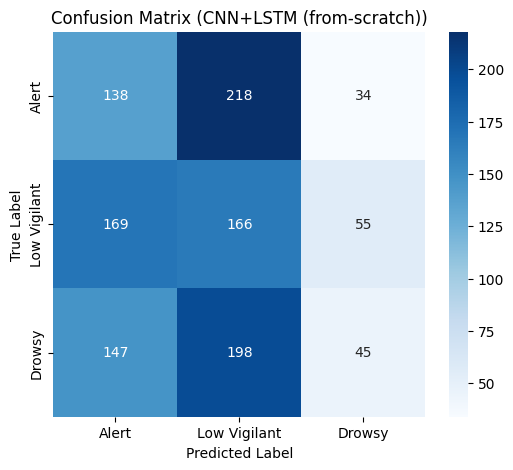


Accuracy by window duration (CNN+LSTM (from-scratch)):
                     accuracy  n_windows
window_duration_sec                     
3.0                  0.300000        540
5.0                  0.305556        360
10.0                 0.294444        180
20.0                 0.266667         90


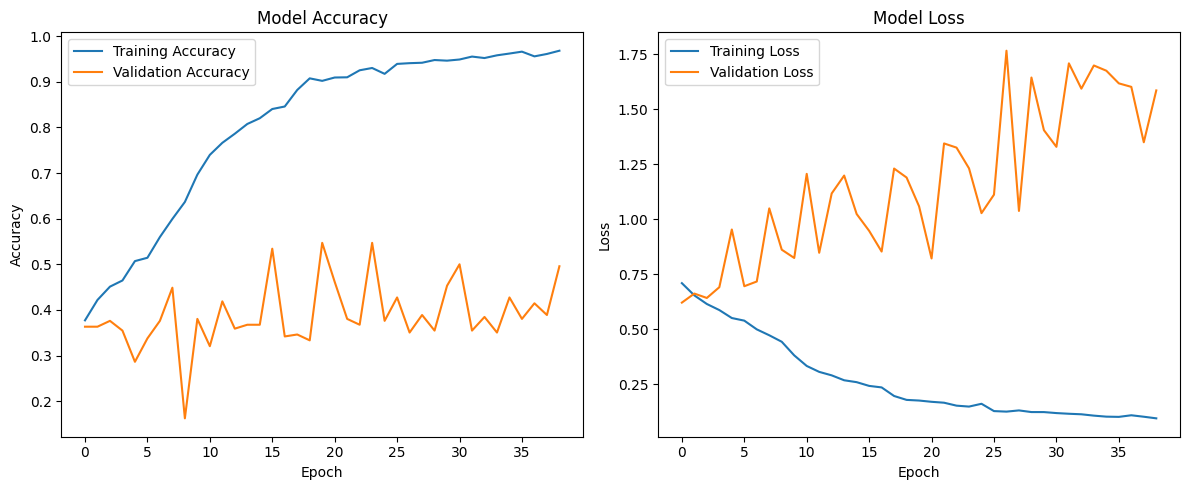

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import numpy as np
from tensorflow.keras.optimizers import Adam

def evaluate_variant(model_path, fallback_model, test_dataset, test_df, variant_label):
    """Loads the best checkpoint (falling back to the in-memory model if the checkpoint file
    isn't found), evaluates against test_dataset, prints a classification report + confusion
    matrix, and returns (y_true, y_pred, per_duration_accuracy) for later comparison.
    """
    custom_objects = {'SparseCategoricalFocalLoss': SparseCategoricalFocalLoss}
    if os.path.exists(model_path):
        print(f"Loading best {variant_label} checkpoint from {model_path}...")
        # Note: compile=False avoids certain loading errors; we re-compile or just use for inference.
        model_eval = tf.keras.models.load_model(model_path, custom_objects=custom_objects, compile=False)

        # Fix for cuDNN error: Ensure LSTM layers use_cudnn=False for pre-padded sequences
        for layer in model_eval.layers:
            if isinstance(layer, tf.keras.layers.LSTM):
                layer.use_cudnn = False

        # RE-COMPILE: Necessary because we loaded with compile=False
        model_eval.compile(optimizer=Adam(learning_rate=0.001), loss=build_loss(), metrics=['accuracy'])
    else:
        print(f"Best {variant_label} checkpoint not found, falling back to in-memory model.")
        model_eval = fallback_model

    loss, accuracy = model_eval.evaluate(test_dataset, verbose=0)
    y_true = np.concatenate([y.numpy() for _, y in test_dataset])
    y_pred = np.argmax(model_eval.predict(test_dataset), axis=1)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n{variant_label} Test Loss: {loss:.4f}")
    print(f"{variant_label} Test Accuracy: {accuracy:.4f}")
    print(f"{variant_label} Test Macro-F1: {macro_f1:.4f}")
    print(f"\nClassification Report ({variant_label}):")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix ({variant_label})')
    plt.show()

    # --- Per-duration accuracy breakdown -- the question this whole model exists to answer ---
    eval_df = test_df.reset_index(drop=True).copy()
    eval_df['correct'] = (y_true == y_pred)
    per_duration = eval_df.groupby('window_duration_sec')['correct'].agg(['mean', 'count'])
    per_duration.columns = ['accuracy', 'n_windows']
    print(f"\nAccuracy by window duration ({variant_label}):")
    print(per_duration)

    return y_true, y_pred, per_duration


y_true_scratch, y_pred_scratch, per_duration_scratch = evaluate_variant(
    os.path.join(models_folder, 'best_cnn_lstm_scratch.keras'),
    model_scratch, test_ds, df_test, 'CNN+LSTM (from-scratch)',
)

if 'history_scratch' in globals():
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_scratch.history['accuracy'], label='Training Accuracy')
    plt.plot(history_scratch.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_scratch.history['loss'], label='Training Loss')
    plt.plot(history_scratch.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.tight_layout()
    plt.show()

## MobileNetV2 Transfer-Learning Variant (Frozen Backbone → Fine-Tune)

Same two-phase recipe as 07: train the new head (`TimeDistributed(MobileNetV2) → LSTM → Dense`)
to convergence with the pretrained backbone completely frozen first, then unfreeze a small number
of the backbone's final layers and continue at a much lower learning rate. Uses `train_ds_mobilenet`/
`val_ds_mobilenet`/`test_ds_mobilenet` (the `IMG_SIZE_MOBILENET=128` pipeline, not the from-scratch
model's 96×96 one) and the same `weight_dict`/val-macro-F1-based callback pattern as the
from-scratch model above, so any accuracy/recall difference between the two backbones is
attributable to architecture and resolution, not to a different training setup.


In [10]:
mobilenet_extractor, mobilenet_base = build_mobilenet_feature_extractor(
    IMG_SIZE_MOBILENET, alpha=1.0, trainable_backbone=False,
)
model_mobilenet = build_cnn_lstm(mobilenet_extractor, img_size=IMG_SIZE_MOBILENET,
                                  name='cnn_lstm_mobilenet')
model_mobilenet.summary()

macro_f1_cb_mn = MacroF1Callback(val_ds_mobilenet)
early_stopping_mn = EarlyStopping(monitor='val_macro_f1', mode='max', patience=15,
                                   restore_best_weights=True)
checkpoint_mn_frozen = ModelCheckpoint(
    filepath=os.path.join(models_folder, 'best_cnn_lstm_mobilenet_frozen.keras'),
    monitor='val_macro_f1', mode='max', save_best_only=True,
)
reduce_lr_mn = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)

print("🚀 Training CNN+LSTM (MobileNetV2 backbone, frozen)...")
history_mobilenet_frozen = model_mobilenet.fit(
    train_ds_mobilenet,
    epochs=100,
    validation_data=val_ds_mobilenet,
    callbacks=[macro_f1_cb_mn, early_stopping_mn, checkpoint_mn_frozen, reduce_lr_mn],
    class_weight=weight_dict,
    verbose=1,
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "cnn_lstm_mobilenet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer) │ (None, 20, 128,   │          0 │ -                 │
│                     │ 128, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 20, 64)    │  2,339,968 │ images[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (InputLayer)   │ (None, 20)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     33,024 │ time_distributed… │
│                     │                   │            │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │        195 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,373,187 (9.05 MB)

 Trainable params: 115,203 (450.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

🚀 Training CNN+LSTM (MobileNetV2 backbone, frozen)...
Epoch 1/100
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 460s 300ms/step - accuracy: 0.4435 - loss: 0.6601 - val_accuracy: 0.3034 - val_loss: 0.7064 - val_macro_f1: 0.3133 - learning_rate: 0.0010
Epoch 2/100
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 65s 53ms/step - accuracy: 0.6591 - loss: 0.4235 - val_accuracy: 0.3504 - val_loss: 0.9626 - val_macro_f1: 0.3201 - learning_rate: 0.0010
Epoch 3/100
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 64s 52ms/step - accuracy: 0.7261 - loss: 0.3543 - val_accuracy: 0.3932 - val_loss: 0.7584 - val_macro_f1: 0.3454 - learning_rate: 0.0010
Epoch 4/100
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 63s 52ms/step - accuracy: 0.7591 - loss: 0.3072 - val_accuracy: 0.3632 - val_loss: 1.3882 - val_macro_f1: 0.3285 - learning_rate: 0.0010
Epoch 5/100
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 64s 52ms/step - accuracy: 0.7463 - loss: 0.3261 - val_accuracy: 0.3718 - val_loss: 1.4099 - val_macro_f1: 0.2900 - learning_rate: 0.0010
Epoch 6/100
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 6

### Fine-Tuning Phase

Unfreeze the last ~30 layers of the MobileNetV2 base and continue at a much lower learning rate
(`1e-5` vs. the head phase's `1e-3`), same reasoning as 07. One real difference from 07 here: the
MobileNetV2 base is nested *inside* the `TimeDistributed`-wrapped feature extractor sub-model,
not a direct top-level sub-model of a flat functional model like 07's — 07's
`next(l for l in model.layers if isinstance(l, tf.keras.Model))` wouldn't find it here, so
`_find_mobilenet_base` below walks into the `TimeDistributed` layer's wrapped `.layer` first.


In [11]:
best_frozen_path = os.path.join(models_folder, 'best_cnn_lstm_mobilenet_frozen.keras')
custom_objects = {'SparseCategoricalFocalLoss': SparseCategoricalFocalLoss}

print(f"Loading best frozen-head checkpoint from {best_frozen_path}...")
# Load with compile=False to allow manual modification of layer attributes before re-compiling
model_mobilenet_ft = tf.keras.models.load_model(best_frozen_path, custom_objects=custom_objects, compile=False)

# Fix for cuDNN error: Ensure LSTM layers use_cudnn=False for pre-padded sequences
for layer in model_mobilenet_ft.layers:
    if isinstance(layer, tf.keras.layers.LSTM):
        layer.use_cudnn = False

def _find_mobilenet_base(model):
    """Walks into the TimeDistributed-wrapped feature extractor to find the nested MobileNetV2
    base -- see the markdown cell above for why this differs from 07's flat top-level lookup.
    """
    for layer in model.layers:
        if isinstance(layer, TimeDistributed):
            inner = layer.layer
            for sub in inner.layers:
                if isinstance(sub, tf.keras.Model) and 'mobilenetv2' in sub.name.lower():
                    return sub
    raise ValueError("Could not locate the MobileNetV2 base layer inside the loaded model.")


base_ft = _find_mobilenet_base(model_mobilenet_ft)
base_ft.trainable = True
FINE_TUNE_UNFREEZE_LAYERS = 30
for layer in base_ft.layers[:-FINE_TUNE_UNFREEZE_LAYERS]:
    layer.trainable = False
for layer in base_ft.layers[-FINE_TUNE_UNFREEZE_LAYERS:]:
    if isinstance(layer, BatchNormalization):
        # Keep BatchNorm's running statistics frozen even among the "unfrozen" layers -- letting
        # it keep computing batch statistics from this project's small batches would destabilize
        # training, independent of which layers are otherwise trainable. Same reasoning as 07.
        layer.trainable = False

FINE_TUNE_LR = 1e-5
# Re-compile is required after loading with compile=False and modifying layer trainability
model_mobilenet_ft.compile(optimizer=Adam(learning_rate=FINE_TUNE_LR), loss=build_loss(),
                            metrics=['accuracy'])

macro_f1_cb_ft = MacroF1Callback(val_ds_mobilenet)
early_stopping_ft = EarlyStopping(monitor='val_macro_f1', mode='max', patience=8,
                                   restore_best_weights=True)
checkpoint_ft = ModelCheckpoint(
    filepath=os.path.join(models_folder, 'best_cnn_lstm_mobilenet_finetuned.keras'),
    monitor='val_macro_f1', mode='max', save_best_only=True,
)
reduce_lr_ft = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-8, verbose=1)

print(f"🚀 Fine-tuning MobileNetV2 (last {FINE_TUNE_UNFREEZE_LAYERS} backbone layers, "
      f"lr={FINE_TUNE_LR})...")
history_mobilenet_ft = model_mobilenet_ft.fit(
    train_ds_mobilenet,
    epochs=20,
    validation_data=val_ds_mobilenet,
    callbacks=[macro_f1_cb_ft, early_stopping_ft, checkpoint_ft, reduce_lr_ft],
    class_weight=weight_dict,
    verbose=1,
)

model_mobilenet_ft.save(cnn_lstm_mobilenet_model_path)
print(f"💾 Model saved: {cnn_lstm_mobilenet_model_path}")

Loading best frozen-head checkpoint from /content/drive/MyDrive/Argus/models/best_cnn_lstm_mobilenet_frozen.keras...
🚀 Fine-tuning MobileNetV2 (last 30 backbone layers, lr=1e-05)...
Epoch 1/20
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 332s 230ms/step - accuracy: 0.7811 - loss: 0.2891 - val_accuracy: 0.3974 - val_loss: 0.9404 - val_macro_f1: 0.3317 - learning_rate: 1.0000e-05
Epoch 2/20
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 187s 165ms/step - accuracy: 0.8330 - loss: 0.2270 - val_accuracy: 0.4573 - val_loss: 0.9639 - val_macro_f1: 0.3803 - learning_rate: 1.0000e-05
Epoch 3/20
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 187s 164ms/step - accuracy: 0.8690 - loss: 0.1816 - val_accuracy: 0.3974 - val_loss: 1.0613 - val_macro_f1: 0.3448 - learning_rate: 1.0000e-05
Epoch 4/20
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 186s 164ms/step - accuracy: 0.8942 - loss: 0.1669 - val_accuracy: 0.3974 - val_loss: 0.9798 - val_macro_f1: 0.2977 - learning_rate: 1.0000e-05
Epoch 5/20
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9037 - l

## MobileNetV2 Evaluation + Scratch vs. MobileNetV2 Comparison

Same `evaluate_variant` helper as the from-scratch model above, run against the fine-tuned
checkpoint (and the frozen-only checkpoint, for a full three-way comparison). The comparison
table combines both backbones' overall numbers **and** their per-duration breakdowns, so it
answers two questions at once: which backbone generalizes better to held-out subjects, and
whether either one actually benefits from more temporal context.


Loading best CNN+LSTM (MobileNetV2, frozen) checkpoint from /content/drive/MyDrive/Argus/models/best_cnn_lstm_mobilenet_frozen.keras...
293/293 ━━━━━━━━━━━━━━━━━━━━ 66s 150ms/step

CNN+LSTM (MobileNetV2, frozen) Test Loss: 1.0278
CNN+LSTM (MobileNetV2, frozen) Test Accuracy: 0.3368
CNN+LSTM (MobileNetV2, frozen) Test Macro-F1: 0.3340

Classification Report (CNN+LSTM (MobileNetV2, frozen)):
              precision    recall  f1-score   support

       Alert       0.39      0.44      0.42       390
Low Vigilant       0.31      0.27      0.29       390
      Drowsy       0.30      0.29      0.30       390

    accuracy                           0.34      1170
   macro avg       0.33      0.34      0.33      1170
weighted avg       0.33      0.34      0.33      1170



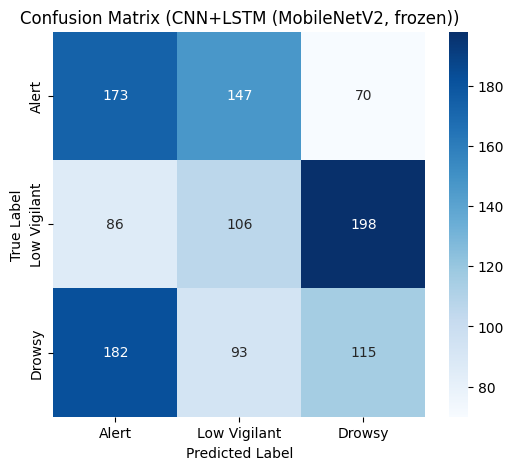


Accuracy by window duration (CNN+LSTM (MobileNetV2, frozen)):
                     accuracy  n_windows
window_duration_sec                     
3.0                  0.329630        540
5.0                  0.344444        360
10.0                 0.338889        180
20.0                 0.344444         90
Loading best CNN+LSTM (MobileNetV2, fine-tuned) checkpoint from /content/drive/MyDrive/Argus/models/best_cnn_lstm_mobilenet_finetuned.keras...
293/293 ━━━━━━━━━━━━━━━━━━━━ 64s 149ms/step

CNN+LSTM (MobileNetV2, fine-tuned) Test Loss: 1.4262
CNN+LSTM (MobileNetV2, fine-tuned) Test Accuracy: 0.3368
CNN+LSTM (MobileNetV2, fine-tuned) Test Macro-F1: 0.3130

Classification Report (CNN+LSTM (MobileNetV2, fine-tuned)):
              precision    recall  f1-score   support

       Alert       0.30      0.31      0.31       390
Low Vigilant       0.35      0.56      0.43       390
      Drowsy       0.38      0.14      0.20       390

    accuracy                           0.34      1170
   

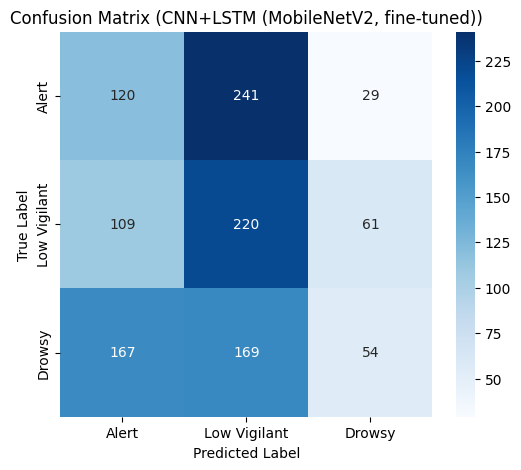


Accuracy by window duration (CNN+LSTM (MobileNetV2, fine-tuned)):
                     accuracy  n_windows
window_duration_sec                     
3.0                  0.333333        540
5.0                  0.341667        360
10.0                 0.333333        180
20.0                 0.344444         90

=== Scratch vs. MobileNetV2 (frozen) vs. MobileNetV2 (fine-tuned) ===
                                    Test Accuracy  Macro F1  Alert Recall  \
Variant                                                                     
CNN+LSTM (from-scratch)                    0.2983    0.2801        0.3538   
CNN+LSTM (MobileNetV2, frozen)             0.3368    0.3340        0.4436   
CNN+LSTM (MobileNetV2, fine-tuned)         0.3368    0.3130        0.3077   

                                    Low Vigilant Recall  Drowsy Recall  
Variant                                                                 
CNN+LSTM (from-scratch)                          0.4256         0.1154  
CNN+LSTM (M

In [12]:
y_true_mn_frozen, y_pred_mn_frozen, per_duration_mn_frozen = evaluate_variant(
    os.path.join(models_folder, 'best_cnn_lstm_mobilenet_frozen.keras'),
    model_mobilenet, test_ds_mobilenet, df_test, 'CNN+LSTM (MobileNetV2, frozen)',
)

y_true_mn_ft, y_pred_mn_ft, per_duration_mn_ft = evaluate_variant(
    os.path.join(models_folder, 'best_cnn_lstm_mobilenet_finetuned.keras'),
    model_mobilenet_ft, test_ds_mobilenet, df_test, 'CNN+LSTM (MobileNetV2, fine-tuned)',
)

# --- Overall comparison table: scratch vs. MobileNetV2 frozen vs. fine-tuned ---
comparison_rows = []
for variant_name, y_pred_variant in [
    ('CNN+LSTM (from-scratch)', y_pred_scratch),
    ('CNN+LSTM (MobileNetV2, frozen)', y_pred_mn_frozen),
    ('CNN+LSTM (MobileNetV2, fine-tuned)', y_pred_mn_ft),
]:
    report = classification_report(y_true_scratch, y_pred_variant, target_names=CLASS_NAMES,
                                    output_dict=True, zero_division=0)
    comparison_rows.append({
        'Variant': variant_name,
        'Test Accuracy': report['accuracy'],
        'Macro F1': report['macro avg']['f1-score'],
        'Alert Recall': report['Alert']['recall'],
        'Low Vigilant Recall': report['Low Vigilant']['recall'],
        'Drowsy Recall': report['Drowsy']['recall'],
    })
comparison_df = pd.DataFrame(comparison_rows).set_index('Variant')
print("\n=== Scratch vs. MobileNetV2 (frozen) vs. MobileNetV2 (fine-tuned) ===")
print(comparison_df.round(4))

# --- Per-duration comparison table -- does more temporal context actually help, per backbone? ---
per_duration_comparison = pd.concat(
    {
        'from-scratch': per_duration_scratch['accuracy'],
        'mobilenet_frozen': per_duration_mn_frozen['accuracy'],
        'mobilenet_finetuned': per_duration_mn_ft['accuracy'],
    },
    axis=1,
)
print("\n=== Accuracy by window duration, per backbone ===")
print(per_duration_comparison.round(4))


## Reading This Result Alongside the Other Models

This is the most complete architecture tried so far — real temporal context *and* raw-pixel
visual cues at once — but per the "Calibrated expectation" note at the top of this notebook, it's
also the most data-hungry, and neither of those facts is evidence about which one wins in
practice on this dataset's subject count. Read the numbers above alongside:

- `07_cnn_training.ipynb`'s single-frame CNN (36.67% accuracy, 0.3614 macro-F1, from-scratch;
  16.81% accuracy, MobileNetV2) — if this notebook's from-scratch result doesn't clearly beat
  07's, that's evidence the single-instant-in-time limitation wasn't actually the binding
  constraint, or that this model's added capacity overfit before it generalized (see 09's
  "Calibrated expectation" and the root `CLAUDE.md`'s RandomForest/Dense NN findings for the
  same root-cause question asked of a different architecture).
- The per-duration breakdown above specifically: if accuracy doesn't trend with
  `window_duration_sec` (more context -> better), that's a direct answer to whether the extra
  temporal modeling is paying for itself at all here, independent of the backbone question.
- Whether the MobileNetV2 variant's `alpha=1.0`/`IMG_SIZE_MOBILENET=128` change actually avoided
  07's zero-recall-on-`Low Vigilant` collapse. If it didn't, that's a real result narrowing down
  the cause (rules out the resolution/alpha theory), not something to silently retune further
  here.

**Once this has actually been run:** update `notebook/CLAUDE.md`'s pipeline map and "What we
found" section with the real numbers (both backbones, plus the per-duration breakdown) and mark
`10_cnn_lstm_training.ipynb`'s pipeline-map row as run rather than "does not exist yet" — per
this project's standard, state whatever the numbers actually are, not an aspirational rounding.

**Not built here, worth doing next depending on what the numbers above show:**
- A subject-fold cross-validation diagnostic (mirroring 07's `RUN_CROSS_VALIDATION`) if the
  single-fold number looks encouraging but a reliability check is needed before trusting it.
- If this underperforms or overfits, see `notebook/CLAUDE.md`'s "Cheaper options considered
  alongside the full CNN+LSTM build" for lower-data-cost fallbacks already discussed (a
  late-fusion ensemble of RandomForest/Dense NN/CNN, or feeding 07's frozen CNN embedding into
  the existing geometric LSTM instead of training a CNN from scratch inside the recurrent loop).
